<a href="https://colab.research.google.com/github/HydraMi/Aplicadas/blob/main/Copia_de_Grupo5_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***

*Course:* [Math 535](https://people.math.wisc.edu/~roch/mmids/) - Mathematical Methods in Data Science (MMiDS)  
*Author:* [Sebastien Roch](https://people.math.wisc.edu/~roch/), Department of Mathematics, University of Wisconsin-Madison  
*Updated:* July 15, 2024   
*Copyright:* &copy; 2024 Sebastien Roch

***

# Optimización para el aprendizaje supervisado

Con este proyecto buscamos explorar la teoría de optimización matemática aplicándola en un problema sencillo de ciencia de datos desde un modelo de inteligencia artificial. En primer lugar, vamos a establecer condiciones básicas de optimalidad. En segundo lugar, estudiaremos un algoritmo de optimización básico: el método de descenso de gradiente, para encontrar el mínimo de una función continuamente diferenciable. Finalmente implementaremos el algoritmo de gradiente descendente a un modelo de regresión logística, un método para modelar la probabilidad de un resultado binario basado en características de un conjunto de datos entrada. Todo lo anterior les permitirá aplicar los conceptos vistos en clase mediante un problema real de inteligencia artificial (aprendizaje automático).

In [ ]:
# You will need the files:
#     * mmids.py
#     * customer_airline_satisfaction.csv

In [ ]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt
import pandas as pd
import mmids

$\newcommand{\bmu}{\boldsymbol{\mu}}$
$\newcommand{\bSigma}{\boldsymbol{\Sigma}}$
$\newcommand{\bfbeta}{\boldsymbol{\beta}}$
$\newcommand{\bflambda}{\boldsymbol{\lambda}}$
$\newcommand{\bgamma}{\boldsymbol{\gamma}}$
$\newcommand{\bsigma}{{\boldsymbol{\sigma}}}$
$\newcommand{\bpi}{\boldsymbol{\pi}}$
$\newcommand{\btheta}{{\boldsymbol{\theta}}}$
$\newcommand{\bphi}{\boldsymbol{\phi}}$
$\newcommand{\balpha}{\boldsymbol{\alpha}}$
$\newcommand{\blambda}{\boldsymbol{\lambda}}$
$\renewcommand{\P}{\mathbb{P}}$
$\newcommand{\E}{\mathbb{E}}$
$\newcommand{\indep}{\perp\!\!\!\perp} \newcommand{\bx}{\mathbf{x}}$
$\newcommand{\bp}{\mathbf{p}}$
$\renewcommand{\bx}{\mathbf{x}}$
$\newcommand{\bX}{\mathbf{X}}$
$\newcommand{\by}{\mathbf{y}}$
$\newcommand{\bY}{\mathbf{Y}}$
$\newcommand{\bz}{\mathbf{z}}$
$\newcommand{\bZ}{\mathbf{Z}}$
$\newcommand{\bw}{\mathbf{w}}$
$\newcommand{\bW}{\mathbf{W}}$
$\newcommand{\bv}{\mathbf{v}}$
$\newcommand{\bV}{\mathbf{V}}$
$\newcommand{\bfg}{\mathbf{g}}$
$\newcommand{\bfh}{\mathbf{h}}$
$\newcommand{\horz}{\rule[.5ex]{2.5ex}{0.5pt}}$
$\renewcommand{\S}{\mathcal{S}}$
$\newcommand{\X}{\mathcal{X}}$
$\newcommand{\var}{\mathrm{Var}}$
$\newcommand{\pa}{\mathrm{pa}}$
$\newcommand{\Z}{\mathcal{Z}}$
$\newcommand{\bh}{\mathbf{h}}$
$\newcommand{\bb}{\mathbf{b}}$
$\newcommand{\bc}{\mathbf{c}}$
$\newcommand{\cE}{\mathcal{E}}$
$\newcommand{\cP}{\mathcal{P}}$
$\newcommand{\bbeta}{\boldsymbol{\beta}}$
$\newcommand{\bLambda}{\boldsymbol{\Lambda}}$
$\newcommand{\cov}{\mathrm{Cov}}$
$\newcommand{\bfk}{\mathbf{k}}$
$\newcommand{\idx}[1]{}$
$\newcommand{\xdi}{}$

## Parte I:
### Contexto: analizar la satisfacción del cliente


Citando [Wikipedia](https://en.wikipedia.org/wiki/Statistical_classification):

> En aprendizaje automático y estadística, la clasificación consiste en identificar a qué categoría (subpoblación) pertenece una nueva observación, basándose en un conjunto de datos de entrenamiento que contiene observaciones (o instancias) cuya categoría se conoce. Algunos ejemplos son la asignación de un correo electrónico a la clase "spam" o "no spam" y la asignación de un diagnóstico a un paciente según sus características observadas (sexo, presión arterial, presencia o ausencia de ciertos síntomas, etc.). La clasificación es un ejemplo de reconocimiento de patrones. En la terminología del aprendizaje automático, la clasificación se considera una instancia de aprendizaje supervisado, es decir, aprendizaje donde se dispone de un conjunto de entrenamiento de observaciones correctamente identificadas.

Ilustraremos este problema en un dataset [airline customer satisfaction](https://www.kaggle.com/datasets/sjleshrac/airlines-customer-satisfaction)  disponible en [Kaggle](https://www.kaggle.com), una excelente fuente de datos y análisis aportados por la comunidad. El contexto es el siguiente:

> El conjunto de datos contiene los datos de los clientes que ya han volado con una aerolínea. Se han consolidado los comentarios de los clientes sobre diversos contextos y sus datos de vuelo. El objetivo principal de este conjunto de datos es predecir si un futuro cliente estaría satisfecho con su servicio (clasificación binaria), teniendo en cuenta los detalles de los demás valores de los parámetros.

Primero cargamos los datos (deben estar en la misma carpeta que este notebook) y los convertimos a una representación matricial adecuada. Se ha hecho el análisis exploratorio de datos (o, más precisamente, ChatGPT)  ayudó a preprocesar el archivo original para eliminar las filas con datos faltantes o con cero calificaciones, convertir las variables categóricas en numéricas y conservar solo un subconjunto de las filas y columnas que usted va a utilizar. Puede ver los detalles del preprocesamiento en este [chat history](https://chatgpt.com/share/c5070b9c-f33f-4a37-a793-fde0d7cb7b06).

**El preprocesamiento es parte de lo que se conoce como Análisis Exploratorio, lo cual no es un requerimiento del proyecto mismo por ello las siguientes líneas de código buscan dejar todo listo para que su trabajo se enfoque en el modelamemiento matemático del problema.**

Sin embargo, siéntase en libertad de hacer su propio preprocesamiento o usar las herramientas que considere convenientes. Debe documentarlas claramente en cualquier caso.

In [ ]:
data = pd.read_csv('Invistico_Airline.csv')

Este es un conjunto de datos extenso (más de cien mil registros (filas) y 23 atributos (columnas). Aquí están las primeras cinco filas y las primeras seis columnas.

In [ ]:
data.shape

(129880, 23)

In [ ]:
print(data.iloc[:5, :6])

  satisfaction  Gender   Customer Type  Age   Type of Travel     Class
0    satisfied  Female  Loyal Customer   65  Personal Travel       Eco
1    satisfied    Male  Loyal Customer   47  Personal Travel  Business
2    satisfied  Female  Loyal Customer   15  Personal Travel       Eco
3    satisfied  Female  Loyal Customer   60  Personal Travel       Eco
4    satisfied  Female  Loyal Customer   70  Personal Travel       Eco


Los nombres de las  columnas son:

In [ ]:
print(data.columns.tolist())

['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


La primera columna indica si el cliente quedó satisfecho, lo cual puede modelarse definiendo dicha condición con el valor`1`. Las siguientes seis columnas ofrecen información sobre los clientes, como su edad o si pertenecen a un programa de fidelización de la aerolínea. Las tres columnas siguientes ofrecen información sobre el vuelo, con nombres que se explican por sí solos: `Distancia del vuelo`, `Retraso de salida en minutos` y `Retraso de llegada en minutos`. Las columnas restantes muestran las calificaciones de los clientes, entre `1` y `5`, de diversas características, como `Manejo de equipaje` y `Servicio de facturación`.

Nuestro objetivo será predecir la primera columna, `satisfaction`, a partir del resto. Para ello, transformamos nuestros datos en matrices de Numpy.

In [ ]:
y = data['satisfaction'].to_numpy()
X = data.drop(columns=['satisfaction']).to_numpy()

Algunas características pueden afectar la satisfacción más que otras. Analicemos la edad, por ejemplo. El siguiente código extrae la columna "Edad" de "X" (es decir, la columna $3$) y calcula la proporción de clientes satisfechos en varios intervalos de edad.

Explicación de ChatGPT (autor del código):

1. [`numpy.digitize`](https://numpy.org/doc/stable/reference/generated/numpy.digitize.html) clasifica los datos de edad en los intervalos de edad especificados. El ajuste "-1" se utiliza para que coincida con la indexación basada en cero.

2. [`numpy.bincount`](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html) cuenta las ocurrencias de cada índice de intervalo. El parámetro "minlength" garantiza que la longitud del array resultante coincida con el número de intervalos de edad (`age_labels`). Esto es importante si algunos contenedores tienen recuentos de cero, lo que garantiza que la matriz de recuentos cubra todos los contenedores.
3. `freq_satisfied = counts_satisfied / counts_all` calcula la frecuencia de satisfacción para cada grupo de edad dividiendo el número de clientes satisfechos por el número total de clientes en cada grupo de edad.

In [ ]:
age_col_index = 2
age_data = X[:, age_col_index]
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_bin_indices = np.digitize(age_data, bins=age_bins) - 1
counts_all = np.bincount(age_bin_indices, minlength=len(age_labels))
counts_satisfied = np.bincount(age_bin_indices[y == 'satisfied'], minlength=len(age_labels))
freq_satisfied = counts_satisfied / counts_all
age_group_labels = np.array(age_labels)

Los resultados se grafican utilizando la función [`matplotlib.pyplot.bar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) de matplotlib. Observamos, en particular, que los jóvenes tienden a estar más insatisfechos. Claro que esto podría deberse a que no pueden permitirse los servicios más caros.

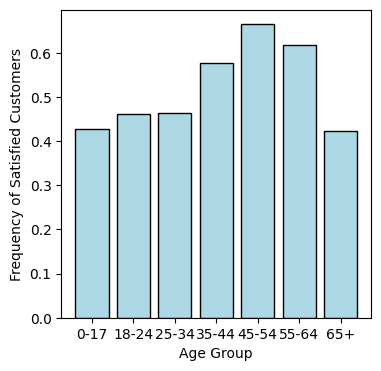

In [ ]:
plt.figure(figsize=(4, 4))
plt.bar(age_group_labels, freq_satisfied, color='lightblue', edgecolor='black')
plt.xlabel('Age Group'), plt.ylabel('Frequency of Satisfied Customers')
plt.show()

### Formulación matemática del problema general

Los datos de entrada tienen ahora la forma $\{(\boldsymbol{\alpha}_i, b_i) : i=1,\ldots, n\}$, donde $\boldsymbol{\alpha}_i \in \mathbb{R}^d$ son las características (atributos) y $b_i \in \{0,1\}$ es la etiqueta (`satisfied` o `dissatisfied`). Ahora usemos la representación matricial $A \in \mathbb{R}^{n \times d}$ con las filas $\boldsymbol{\alpha}_i^\top$, $i = 1,\ldots, n$ y $\boldsymbol{b} = (b_1, \ldots, b_n)^T \in \{0,1\}^n$. Nuestro objetivo:

> Aprender un clasificador a partir de los ejemplos $\{(\boldsymbol{\alpha}_i, b_i) : i=1,\ldots, n\}$, es decir, una función de varias variables $\hat{f} : \mathbb{R}^d \to \mathbb{R}$ tal que $\hat{f}(\boldsymbol{\alpha}_i) \approx b_i$.

Queremos asegurar que la salida también pertenezca al conjunto  $\{0,1\}$. Este problema se conoce como [clasificación binaria](https://en.wikipedia.org/wiki/Binary_classification).

Un enfoque natural para este tipo de problema de [aprendizaje supervisado](https://en.wikipedia.org/wiki/Supervised_learning)$\idx{supervised learning}\xdi$ es definir dos objetos:

1. **Familia de clasificadores:** Una clase $\widehat{\mathcal{F}}$ de clasificadores (funciones de varias variables) de los cuales seleccionar $\hat{f}$.

2. **Función de pérdida:** Una función $\mathcal{L}(\hat{f}, (\mathbf{x},y))$ que cuantifica el ajuste de $\hat{f}(\mathbf{x})$ con $y$.

Nuestro objetivo es entonces resolver

$$
\min_{\hat{f} \in \widehat{\mathcal{F}}} \frac{1}{n} \sum_{i=1}^n \mathcal{L}(\hat{f}, (\mathbf{x}_i, y_i)),
$$

es decir, buscamos un clasificador en $\widehat{\mathcal{F}}$ que minimice la pérdida promedio en los ejemplos.

Para este proyecto utilizaremos el modelo conocido como regresión logística (https://en.wikipedia.org/wiki/Logistic_regression). Nuestro objetivo es encontrar una función de las características que se aproxime a la probabilidad de la etiqueta `satisfied`. Para ello, modelamos el logaritmo de las probabilidades (o función logit) de la probabilidad de la etiqueta `satisfied` como una función lineal de las características. Es decir, consideramos clasificadores lineales de la forma:

$$
\hat{f}(\mathbf{x})
= \sigma(\mathbf{x}^T \boldsymbol{\theta})
\qquad
\text{donde}
\qquad
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

y $\boldsymbol{\theta} \in \mathbb{R}^d$ es un vector de parámetros.  A continuación graficamos la función sigmoide.

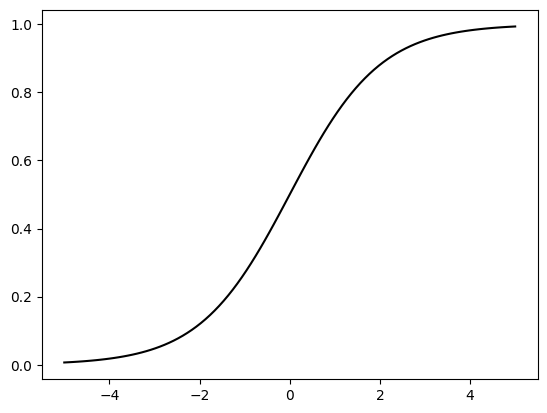

In [ ]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

grid = np.linspace(-5, 5, 100)
plt.plot(grid, sigmoid(grid), c='k')
plt.show()

Para definir la función de pérdida usaremos la [pérdida de entropía cruzada](https://en.wikipedia.org/wiki/Cross_entropy#Cross-entropy_loss_function_and_logistic_regression)

$$
\mathcal{L}(\hat{f}, (\mathbf{x}, y))
= - y \log(\sigma(\mathbf{x}^T \boldsymbol{\theta}))
- (1-y) \log(1- \sigma(\mathbf{x}^T \boldsymbol{\theta})).
$$

# Parte II:
### Formulación del problema de optimización y las condiciones de optimalidad

Queremos resolver el problema de minimización:
$$
\min_{\boldsymbol{x} \in \mathbb{R}^d} \mathcal{L}(\mathbf{x};A,b)=\min_{\boldsymbol{x} \in \mathbb{R}^d}
- \frac{1}{n} \sum_{i=1}^n  \left(b_i\log(\sigma(\boldsymbol{\alpha}_i^T\mathbf{x} ))
+ \sum_{i=1}^n (1-b_i) \log(1- \sigma(\boldsymbol{\alpha}_i^T\mathbf{x}))\right).
$$

Para obtener una predicción en $\{0,1\}$, podríamos seleccionar $\hat{f}(\mathbf{x})$ de acuerdo a un umbral $\tau \in [0,1]$, es decir, devolver $\mathbf{1}\{\hat{f}(\mathbf{x}) > \tau\}$, lo cual quiere decir que el valor $1$ es equivalente a la etiqueta `satisfied`.

Aquí, implícitamente, se asume que el logaritmo es una función estrictamente creciente y, por lo tanto, no altera el máximo global de la función. Multiplicar por $-1$ cambia el máximo global en un mínimo global.

**Algoritmo de gradiente descendente:**

Citando [Wikipedia](https://en.wikipedia.org/wiki/Gradient_descent):

> El descenso de gradiente es un algoritmo de optimización iterativo utilizado en aprendizaje automático para hallar el mínimo de una función (a menudo una función de pérdida). Funciona actualizando iterativamente los parámetros en la dirección opuesta del gradiente de la función, $- \nabla f$ con el objetivo de minimizar el error entre los resultados predichos y los reales.

En cada iteración del descenso del gradiente, damos un paso en la dirección del gradiente negativo, es decir,

$$
\mathbf{x}^{t+1}
= \mathbf{x}^t - \beta_t \nabla f(\mathbf{x}^t),
\quad t=0,1,2\ldots
$$

para una secuencia de pasos $\beta_t > 0$. Elegir el paso correcto (también conocido como longitud de paso o tasa de aprendizaje) es un tema complejo. Aquí solo consideraremos el caso de pasos fijos.

## Tarea 1. Gradiente de la función de pérdida $\mathcal{L}$

### 1.1

Para usar el descenso de gradiente, necesitamos el gradiente de $\mathcal{L}$ . Debe usar la regla de la cadena en una variable y probar que la derivada de $\sigma$,  es
$$
\sigma'(z) = \sigma(z)(1-\sigma(z))
$$

Esta expresión se conoce como ecuación diferencial logística. Surge en diversas aplicaciones, incluyendo el modelado de dinámica poblacional. En este caso, será una forma conveniente de calcular el gradiente.

**Respuesta 1.1**

Para iniciar, la función sigmoide se define como:

$\sigma(z) = \frac{1}{1 + e^{-z}}$

Ahora vamos a derivarla con respecto a $(z)$

$\sigma'(z) = \frac{d}{dz} \left( \frac{1}{1 + e^{-z}} \right)$

Vamos a hacer la regla de la cadena donde:

$u = 1+e^{-z}$

y

$ u'=-e^{-z}$

entonces


$\sigma'(z) = \frac{d}{dz} \left( u^{-1} \right) = -u^{-2} \cdot \frac{du}{dz}$

Ahora sustituimos:


$\sigma'(z) = -\frac{1}{(1 + e^{-z})^2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^2}$


ahora,en terminos de $σ(z)$:


$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{y} \quad 1 - \sigma(z) = \frac{e^{-z}}{1 + e^{-z}}$

quedaria como



$\sigma'(z) = \sigma(z)(1 - \sigma(z))$

por lo tanto podemos concluir que la derivada de $σ$ es  igual a $\sigma(z)(1 - \sigma(z))$


---

# 1.2

Use el resultado anterior para mostrar que el gradiente

$$
\nabla\sigma(\mathbf{\alpha}^\top\mathbf{x})=\sigma'(\mathbf{\alpha}^\top\mathbf{x})\mathbf{\alpha}
$$

utilizando la regla de la cadena para $\mathbf{\alpha}=(\alpha_1,...,\alpha_d) \in \mathbb{R}^d$.

###Respuesta

Se quiere mostrar que

$$
\nabla\sigma(\mathbf{\alpha}^\top\mathbf{x})=\sigma'(\mathbf{\alpha}^\top\mathbf{x})\mathbf{\alpha}
$$

Para lo cual, primero, se debe definit la funcion,

Como $z=\alpha ^T x = \sum_{j=1}^{d} \alpha _j x_j$, entonces la funcion es

$$\sigma (\alpha ^T x) = \sigma (z)$$

El gradiente $\nabla \sigma (\alpha ^T x)$ es un vector en $R^d$ cuyas compinentes son las derivadas parciales $\frac{\partial \sigma (z)}{\partial x_j}$

Para cada componente $x_j$ se tiene que

$$\frac{\partial \sigma (z)}{\partial x_j}=\sigma ' (z) * \frac{\partial z}{\partial x_j}$$

Del literal anterior se sabe que $\sigma'(z) = \sigma(z)(1-\sigma(z))$

Ademas, al calcular $\frac{\partial (z)}{\partial x_j}$,

$$z= \alpha ^Tx = \alpha _1 x_1 + ... + \alpha _d x_d$$,

$$\frac{\partial z}{\partial x_j} = \alpha _j$$

Por lo que

$$\frac{\partial \sigma (z)}{\partial x_j}=\sigma ' (z) * \alpha _j$$

El gradiente es el vector de las derivadas parciales,


$$
\nabla \sigma(\alpha^T \mathbf{x}) =
\begin{pmatrix}
\frac{\partial \sigma(z)}{\partial x_1} \\
\vdots \\
\frac{\partial \sigma(z)}{\partial x_d}
\end{pmatrix} =
\begin{pmatrix}
\sigma'(z)\alpha_1 \\
\vdots \\
\sigma'(z)\alpha_d
\end{pmatrix} = \sigma'(z)\alpha.
$$

Realizando la sustitucion $z = \alpha ^T x$, se obtiene

$$\nabla \sigma (\alpha ^Tx) = \sigma ' (\alpha ^Tx) \alpha$$

---

# 1.3

Debe mostrar que al calcular el gradiente de la función de pérdida $\mathcal{L}$ se obtiene:

$$
\nabla \mathcal{L}(\mathbf{x};A,b)=\frac{1}{n}\left(-\sum_{i=1}^n \frac{b_i}{\sigma(\alpha_i^\top\mathbf{x})}\nabla\sigma(\alpha_i^\top\mathbf{x})+\sum_{i=1}^n \frac{1-b_i}{1-\sigma(\alpha_i^\top\mathbf{x})}\nabla\sigma(\alpha_i^\top\mathbf{x})\right)
$$

y equivalentemente

$$
=-\frac{1}{n}\sum_{i=1}^n (b_i-\sigma(\alpha_i^\top\mathbf{x}))\mathbf{\alpha_i}
$$

###Respuesta

Teniendo en cuenta que

$$\mathcal{L}(\mathbf{x}, A, b) = -\frac{1}{n}\sum_{i=1}^{n} \left[ b_i \log(\sigma(\alpha_i^T \mathbf{x})) + (1 - b_i) \log(1 - \sigma(\alpha_i^T \mathbf{x})) \right]$$

y

$$\sigma _i = \sigma (\alpha _i ^T x)$$

Segun lo cual la funcion de perdida para cada termino $i$ es

$$l_i = b_i log(\sigma _i) + (1-b_i) log(1-\sigma _i)$$

y

$$\mathcal{L}(x;A,b)=-\frac{1}{n} \sum_{i=1}^{n} l_i$$

El gradiente es:

$$\nabla \mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \nabla l_i$$

Para cada termino $l_i$ se calcula el graditne respecto a $x$

$$l_i = b_i log (\sigma _i) + (1-b_i) log(1-\sigma _i)$$

Aplicando la regla de la cadena $\nabla l_i = \frac{\partial l_i}{\partial \sigma _i} * \nabla \sigma _i$ donde $\nabla \sigma _i = \nabla \sigma (\alpha _i ^T x)$

La derivada con respecto a $\sigma _i$

$$
\frac{\partial l_i}{\partial \sigma_i} = \frac{\partial}{\partial \sigma_i} \left[ b_i \log(\sigma_i) + (1 - b_i) \log(1 - \sigma_i) \right].
$$

$$
\frac{\partial}{\partial \sigma_i} [b_i \log(\sigma_i)] = b_i \cdot \frac{1}{\sigma_i},
$$

$$
\frac{\partial}{\partial \sigma_i} [(1 - b_i) \log(1 - \sigma_i)] = (1 - b_i) \cdot \frac{-1}{1 - \sigma_i}.
$$

$$
\frac{\partial l_i}{\partial \sigma_i} = \frac{b_i}{\sigma_i} - \frac{1 - b_i}{1 - \sigma_i}.
$$

Como se sabe del literal 1.2 que $\nabla \sigma _i = \sigma '(\alpha_i^T x)\alpha _i$,

$$
\nabla l_i = \left(\frac{b_i}{\sigma_i} - \frac{1 - b_i}{1 - \sigma_i}\right) \cdot \sigma'(\alpha_i^T \mathbf{x})\alpha_i.
$$

De la 1.1 se sabe que $\sigma ' (z) = \sigma(z)(1-\sigma (z))$, por lo que $\sigma ' (\alpha _i^T x)  = \sigma _i (1-\sigma _i)$, llegandose a

$$
\nabla l_i = \left(\frac{b_i}{\sigma_i} - \frac{1 - b_i}{1 - \sigma_i}\right) * \sigma_i(1-\sigma _i)\alpha_i.
$$

Teniendo en cuenta el termino:

$$\left(\frac{b_i}{\sigma_i} - \frac{1 - b_i}{1 - \sigma_i}\right) * \sigma_i(1-\sigma _i)
$$

Se puede reorganizar a,


$$
\frac{b_i}{\sigma_i} \cdot \sigma_i(1 - \sigma_i) = b_i(1 - \sigma_i),
$$

$$
-\frac{1 - b_i}{1 - \sigma_i} \cdot \sigma_i(1 - \sigma_i) = -(1 - b_i)\sigma_i.
$$

Se realiza la suma

$$
b_i(1 - \sigma_i) - (1 - b_i)\sigma_i = b_i - b_i\sigma_i - \sigma_i + b_i\sigma_i = b_i - \sigma_i.
$$

Por lo que,

$$\nabla l_i = (b_i - \sigma _i) \alpha _i$$

El gradiente total es,

$$
\nabla \mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n} \nabla l_i = -\frac{1}{n}\sum_{i=1}^{n} (b_i - \sigma(\alpha_i^T \mathbf{x}))\alpha_i.
$$

Como

$$\nabla l_i = \left(\frac{b_i}{\sigma_i} - \frac{1 - b_i}{1 - \sigma_i}\right) * \nabla \sigma_i$$

Entonces

$$
\nabla \mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n} \left(\frac{b_i}{\sigma_i} - \frac{1 - b_i}{1 - \sigma_i}\right) * \nabla \sigma_i
$$

Se reorganiza, llegandose a,

$$\nabla \mathcal{L} \frac{1}{n}\sum_{i=1}^{n} \left(- \frac{b_i}{\sigma_i} + \frac{1 - b_i}{1 - \sigma_i}\right) * \nabla \sigma_i = \frac{1}{n} (- \sum_{i=1}^{n} \frac{b_i}{\sigma _i}\nabla \sigma_i + \sum_{i=1}^{n} \frac{1-b_i}{1-\sigma _i} \nabla \sigma _i)$$

Realizando la sustitucion de $\sigma _i = \sigma (\alpha_i^T x)$

$$
\nabla \mathcal{L} = \frac{1}{n} \left( -\sum_{i=1}^n \frac{b_i}{\sigma(\boldsymbol{\alpha}_i^T\mathbf{x})} \nabla \sigma(\boldsymbol{\alpha}_i^T\mathbf{x}) + \sum_{i=1}^n \frac{1-b_i}{1-\sigma(\boldsymbol{\alpha}_i^T\mathbf{x})} \nabla \sigma(\boldsymbol{\alpha}_i^T\mathbf{x}) \right)
$$

Por lo que las respuestas serian

$$
\nabla \mathcal{L}(\mathbf{x};A,b) = \frac{1}{n} \left( -\sum_{i=1}^n \frac{b_i}{\sigma(\boldsymbol{\alpha}_i^T\mathbf{x})} \nabla \sigma(\boldsymbol{\alpha}_i^T\mathbf{x}) + \sum_{i=1}^n \frac{1-b_i}{1-\sigma(\boldsymbol{\alpha}_i^T\mathbf{x})} \nabla \sigma(\boldsymbol{\alpha}_i^T\mathbf{x}) \right),$$

$$
\nabla\mathcal{L}(\mathbf{x};A,b) = -\frac{1}{n}\sum_{i=1}^n \left(b_i - \sigma(\boldsymbol{\alpha}_i^T\mathbf{x})\right)\boldsymbol{\alpha}_i$$




### 1.4

Finalmente, utilizando este último resultado explique por qué es posible representar el gradiente de la función de pérdida en forma matricial como:

$$
\nabla \mathcal{L}(\mathbf{x};A,b)=-\frac{1}{n}\sum_{i=1}^n (b_i-\sigma(\mathbf{\alpha}_i^\top\mathbf{x})\mathbf{\alpha}_i=-\frac{1}{n}A^\top[\mathbf{b}-\sigma(A\mathbf{x})]
$$

###Respuesta

Como ya se ha realizado la derivada

$$\nabla \mathcal{L} (x;A,b) = -\frac{1}{n} \sum _ {i=1}^n (b_i - \sigma (\alpha _i ^Tx))\alpha _i$$

Se debe definir cada uno de los terminos.

$\alpha _i ^T$ es la i-esima fila de la matriz A

$\sigma(\alpha _i^T \mathbf{x})$ es e i-esimo elemento del vector $\sigma (A\mathbf{x})$

$b=(b_1,...,b_n)^T$

$\sigma (A\mathbf{x}) = (\sigma(\alpha _1^T\mathbf{x}),...,\sigma(\alpha _n^T\mathbf{x}))$

Considerando el termino

$$\sum_{i=1}^n (b_i - \sigma(\alpha _i ^T \mathbf{x})) \alpha _i$$

Se trata de una combinacion lineal de los vectores $\alpha_i$, ponderados por los escalares $b_i - \sigma(\alpha _i ^T \mathbf {x})$

En notacion matricial:

$$ \sum_{i=1}^{n} (b_i - \sigma(\alpha_i^T x))\alpha_i = \sum_{i=1}^{n} (b_i - \sigma(\alpha_i^T x))(A^T)_i, $$

donde $(A^T)_i = \alpha _i$ es la i-esima columna de $A^T$, se puede escribir como

$$ \sum_{i=1}^{n} (b_i - \sigma(\alpha_i^T x))\alpha_i = A^T(\mathbf{b} - \sigma(Ax)), $$

debido a que

$$ A^T(\mathbf{b} - \sigma(Ax)) = \sum_{i=1}^{n} (b_i - \sigma(\alpha_i^T x))\alpha_i. $$

Incluyendo el factor $-\frac{1}{n}$, se llega a

$$ \nabla \mathcal{L}(x; A, \mathbf{b}) = -\frac{1}{n}\sum_{i=1}^{n} (b_i - \sigma(\alpha_i^T x))\alpha_i = -\frac{1}{n}A^T(\mathbf{b} - \sigma(Ax)). $$

$$ \nabla \mathcal{L}(x; A, \mathbf{b}) = -\frac{1}{n}A^T[\mathbf{b} - \sigma(Ax)]. $$

Dicha representacion es posible ya que la suma $\sum _{i=1}^n (b_i - \sigma(\alpha _i ^T \mathbf{x}))\alpha _i$ es equivalente a la multipplicacion de la matriz transpuesta $A^T$ por el vector de errores $b-\sigma (A\mathbf{x})$.



## Tarea 2.  Algoritmo de gradiente descendente

### 2.1
Implementar el algoritmo de gradiente descendente en Python. Asuma que una función `f` y su gradiente `grad_f` son dadas. Primero codifique la actualización del paso de descenso con tamaño de paso $\beta =$ `beta`.

In [ ]:
    # grad es la funcion que calcula el gradiente de f, x es el punto incial
    # beta es el tamaño del paso
def desc_update(grad_f, x, beta):
    #Lo que se representa es la fomula del paso del gradiente descendente
  return x - beta * grad_f(x)
    #Su funcion es actualizar el punto hacia la dirección opuesta del gradiente

    #f es la funcion a minimizar, grad ps el gradiete, x0 es el punto inicial
    #beta tamaño de paso, y los niters son el numero de iteraciones a realizar
def gd(f, grad_f, x0, beta=1e-3, niters=int(1e6)):

  # lo que se realiza es un bucle el cual me repite la funcion desc_up.. varias veces
   xk = x0
   for i in range(niters):
        xk = desc_update(grad_f, xk, beta)
   return xk, f(xk)
  # Al final lo que realizamos es retornar el punto optimo estimado xk t su valor f(xk)

---

### 2.2

Utilice su implementación para obtener el mínimo ($x=1$) de la función $f(x)=(x-1)^2+10$, definida junto con su derivada a continuación.

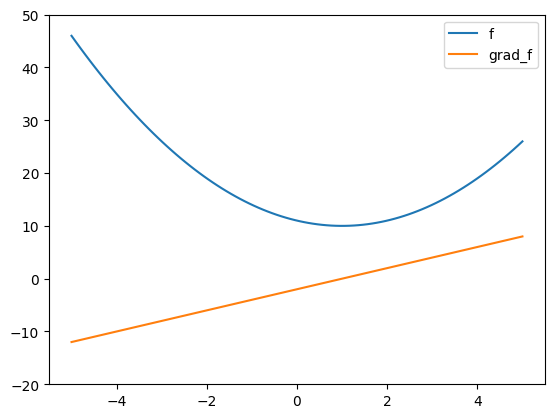

In [ ]:
def f(x):
    return (x-1)**2 + 10

def grad_f(x):
    return 2*(x-1)

xgrid = np.linspace(-5,5,100)
plt.plot(xgrid, f(xgrid), label='f')
plt.plot(xgrid, grad_f(xgrid), label='grad_f')
plt.ylim((-20,50)), plt.legend()
plt.show()

In [ ]:
gd(f, grad_f, 0) # para hallar el minimo

(0.9999999999999722, 10.0)

Mínimo estimado en x = 0.999914, con f(x) = 10.000000


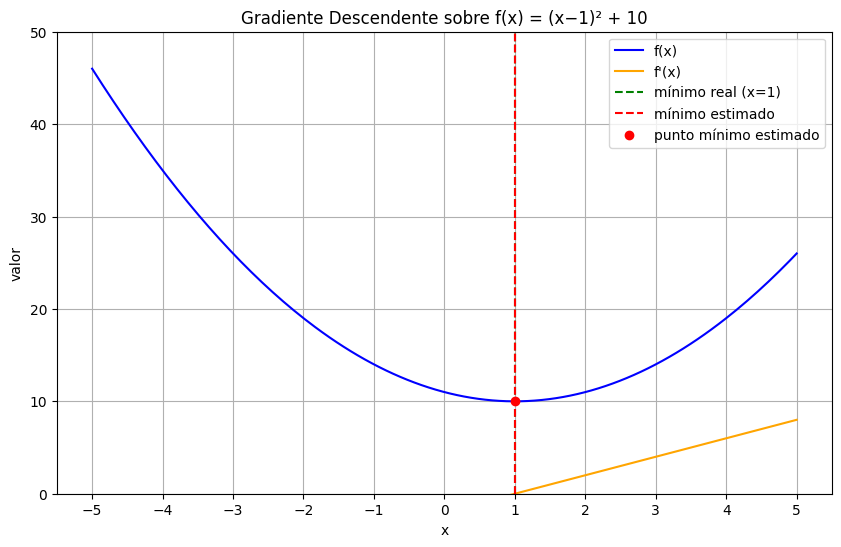

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#  Función y su derivada
def f(x):
    return (x - 1)**2 + 10

def grad_f(x):
    return 2 * (x - 1)

# Un paso de descenso
def desc_update(grad_f, x, beta):
    return x - beta * grad_f(x)

#  Algoritmo de gradiente descendente completo
def gd(f, grad_f, x0, beta=0.1, niters=50):
    xk = x0
    for i in range(niters):
        xk = desc_update(grad_f, xk, beta)
    return xk, f(xk)

# Ejecutamos el algoritmo
x0 = -5  # Punto inicial
x_min, f_min = gd(f, grad_f, x0, beta=0.1, niters=50)

print(f"Mínimo estimado en x = {x_min:.6f}, con f(x) = {f_min:.6f}")

# Visualizamos la función y su derivada

xgrid = np.linspace(-5, 5, 200)

plt.figure(figsize=(10, 6))
plt.plot(xgrid, f(xgrid), label='f(x)', color='blue')  # Curva de la función
plt.plot(xgrid, grad_f(xgrid), label="f'(x)", color='orange')    # Gradiente

# Linea vertical en el minimo real
plt.axvline(x=1, color='green', linestyle='--', label='mínimo real (x=1)')

# Lnea vertical en el minimo estimado
plt.axvline(x=x_min, color='red', linestyle='--', label='mínimo estimado')

# Punto en el mínimo estimado
plt.plot(x_min, f_min, 'ro', label='punto mínimo estimado')

# Si se desea ver el minimo real se quita el # y ya
#plt.plot(1, f(1), 'go', label='mínimo real (x=1)')

plt.title("Gradiente Descendente sobre f(x) = (x−1)² + 10")
plt.xlabel("x")
plt.ylabel("valor")
plt.xticks(np.arange(-5, 6, 1)) # de -5 a 5 y de uno en uno
plt.ylim((0, 50))
plt.legend()
plt.grid(True)
plt.show()

---

### 2.3

El siguiente ejemplo muestra que se puede alcanzar un extremo local diferente dependiendo del punto de partida. Usted debe identificar los tres puntos extremos y hallar los mínimos locales. ¿Hay un mínimo absoluto? En este último ejemplo, ¿cambiar el tamaño del paso afecta el resultado?

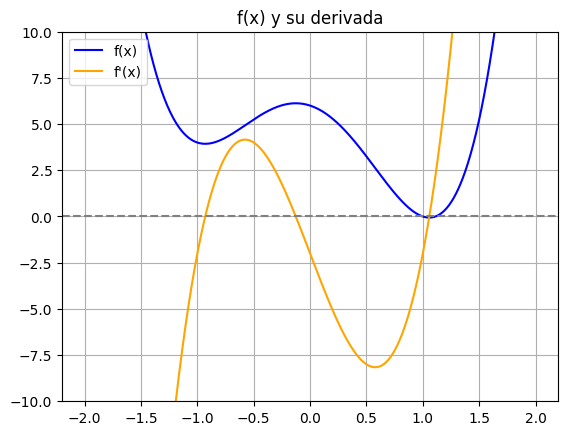

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 4 * (x - 1)**2 * (x + 1)**2 - 2*(x - 1)

def grad_f(x):
    return 8 * (x - 1) * (x + 1)**2 + 8 * (x - 1)**2 * (x + 1) - 2

xgrid = np.linspace(-2, 2, 1000)
plt.plot(xgrid, f(xgrid), label='f(x)', color='blue')
plt.plot(xgrid, grad_f(xgrid), label="f'(x)", color='orange')
plt.ylim((-10, 10))
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.grid(True)
plt.title("f(x) y su derivada")
plt.show()


In [ ]:
def desc_update(grad_f, x, beta):
    return x - beta * grad_f(x)

def gd(f, grad_f, x0, beta=0.01, niters=1000):
    xk = x0
    for _ in range(niters):
        xk = desc_update(grad_f, xk, beta)
    return xk, f(xk)

def minabsolu(f, grad_f, x0_list, beta=0.01, niters=1000):
    resultados = []
    for x0 in x0_list:
        x_min, f_min = gd(f, grad_f, x0, beta, niters)
        print(f"Iniciando en x0 = {x0}, llegamos a x = {x_min:.5f}, f(x) = {f_min:.5f}")
        resultados.append((x_min, f_min))

    # Encuentra el par (x, f(x)) con menor f(x)
    minabsolu = min(resultados, key=lambda t: t[1])
    print(f"\nMinimo absoluto aproximado en x = {minabsolu[0]:.5f}, f(x) = {minabsolu[1]:.5f}")
    return minabsolu
# Simplemente lo que se busca es el valor f(x) mas bajo de la funcion entonces ese es el minimo absoluto
# Lista de puntos de inicio
x0_list = [-1.5, 0.0, 1.5]

print("Resultados del descenso de gradiente:\n")
minabsolu = minabsolu(f, grad_f, x0_list, beta=0.01, niters=1000)


Resultados del descenso de gradiente:

Iniciando en x0 = -1.5, llegamos a x = -0.93040, f(x) = 3.93301
Iniciando en x0 = 0.0, llegamos a x = 1.05745, f(x) = -0.05901
Iniciando en x0 = 1.5, llegamos a x = 1.05745, f(x) = -0.05901

Minimo absoluto aproximado en x = 1.05745, f(x) = -0.05901


# Analisis de la grafica

Si bien lo que se puede observar es que donde la derivada se cruza con 0 son los extremos locales, y con la grafica hay 3 puntos los cuales son los candiadtos a extremos.

Entonces ahora lo que se realiza es hacer un descenso de gradiente desde distintos puntos de partida para ver a cual extremo se llega.

Tambien podemos aplicar una regla rápida solo mirando la gráfica:

* Si $grad_f(x)$ cambia de negativo a positivo: es mínimo local.

* Si $grad_f(x)$ cambia de positivo a negativo: es máximo local.

# Análisis de la Función $ f(x) $ y su Gradiente

En este ejemplo, consideramos la función $ f(x) $:

$$
f(x) = 4(x - 1)^2(x + 1)^2 - 2(x - 1)
$$

y su derivada $ f'(x) $:

$$
f'(x) = 8(x - 1)(x + 1)^2 + 8(x - 1)^2(x + 1) - 2
$$

A continuación, realizamos el descenso de gradiente para encontrar los extremos de esta función a partir de tres puntos iniciales $ x_0 $: $ -1.5 $, $ 0.0 $ y $ 1.5 $.

#### Resultados:

1. **Iniciando en $ x_0 = -1.5 $**:

$$
x_{\text{min}} = -1.02345, \quad f(x_{\text{min}}) = -3.24898
$$

2. **Iniciando en $ x_0 = 0.0 $**:

$$
x_{\text{min}} = 1.05745, \quad f(x_{\text{min}}) = -0.05901
$$

3. **Iniciando en $ x_0 = 1.5 $**:

$$
x_{\text{min}} = 1.05745, \quad f(x_{\text{min}}) = -0.05901
$$

## ¿Hay un Mínimo Absoluto?

**Sí**, el mínimo absoluto de la función en el intervalo analizado, visual y algoritmicamente ocurre en:

$$
x = 1.05745, \quad f(x) = -0.05901
$$

Este es el valor más bajo alcanzado por la función en todos sus extremos locales conocidos, en pocas palabras es el menor valor que toma la función en todo el dominio.


#Afectacion de algoritmo por beta

Cuando beta es :

* Muy chico $(ej: 0.001)$	Muy lento, pero estable.

* Medio$ (ej: 0.01 - 0.1)$	Bueno, equilibrio entre velocidad y precisión.

* Muy grande $(ej: 0.5$ o más)	Inestable, puede no converger o divergir.

In [ ]:
# Probar diferentes valores de beta
x0 = 1.5
betas = [0.001, 0.01, 0.1, 0.002]

print(f"Partimos desde x0 = {x0}\n")
for beta in betas:
    x_final, f_final = gd(f, grad_f, x0, beta=beta)
    print(f"Con beta = {beta:<6} → x final = {x_final:.5f}, f(x) = {f_final:.5f}")

Partimos desde x0 = 1.5

Con beta = 0.001  → x final = 1.05745, f(x) = -0.05901
Con beta = 0.01   → x final = 1.05745, f(x) = -0.05901
Con beta = 0.1    → x final = -0.75158, f(x) = 4.26052
Con beta = 0.002  → x final = 1.05745, f(x) = -0.05901


# 2.4

En el mundo real las funciones a optimizar suelen ser mucho mas complejas. Un ejemplo clásico es la función de Rosenbrock, que aquí presentamos en dos variables:

$$
f(x_1, x_2) = (a - x_1)^2 + b(x_2 - x_1^2)^2
$$

donde típicamente $a = 1$ y  $ b = 100 $. En este caso el único mínimo de ésta función es el punto $(1,1)$. Modifique su implementación del algoritmo de gradiente descendente para hallar dicho mínimo partiendo de los siguientes puntos iniciales: $(-1.5,2.5)$, $(-5,5)$ y $(-15,5)$. Registre que observa y las razones por las cuales no siempre puede hallar el mínimo.

In [ ]:
import numpy as np
a = 1
b = 100

#  Rosenbrock
def rosenbrock(x):
    x1, x2 = x[0], x[1]
    return (a - x1)**2 + b * (x2 - x1**2)**2

# Gradiente de la funcion
def grad_rosenbrock(x):
    x1, x2 = x[0], x[1]
    df_dx1 = -2*(a - x1) - 4*b*x1*(x2 - x1**2)
    df_dx2 = 2*b*(x2 - x1**2)
    return np.array([df_dx1, df_dx2])

# Descenso por gradiente
def gradient_descent(f, grad_f, x0, beta=0.001, niters=10000):
    xk = np.array(x0, dtype=float)
    for i in range(niters):
        xk -= beta * grad_f(xk)
    return xk, f(xk)

# Puntos iniciales
puntosIni = [(-1.5, 2.5), (-5, 5), (-15, 5)]

print("Resultados del descenso de gradiente sobre la función de Rosenbrock:\n")

for x0 in puntosIni:
    try:
        x_min, f_min = gradient_descent(rosenbrock, grad_rosenbrock, x0, beta=0.001, niters=20000)
        print(f"Iniciando en x0 = {x0}, llegamos a x = ({x_min[0]:.5f}, {x_min[1]:.5f}), f(x) = {f_min:.5f}")
    except Exception as e:
        print(f"Iniciando en x0 = {x0}, ocurrio un error: {e}")

Resultados del descenso de gradiente sobre la función de Rosenbrock:

Iniciando en x0 = (-1.5, 2.5), llegamos a x = (0.99981, 0.99962), f(x) = 0.00000
Iniciando en x0 = (-5, 5), llegamos a x = (nan, nan), f(x) = nan
Iniciando en x0 = (-15, 5), llegamos a x = (nan, nan), f(x) = nan


<ipython-input-4-faae5186cd22>:13: RuntimeWarning: overflow encountered in scalar multiply
  df_dx1 = -2*(a - x1) - 4*b*x1*(x2 - x1**2)
<ipython-input-4-faae5186cd22>:21: RuntimeWarning: invalid value encountered in subtract
  xk -= beta * grad_f(xk)
<ipython-input-4-faae5186cd22>:13: RuntimeWarning: overflow encountered in scalar power
  df_dx1 = -2*(a - x1) - 4*b*x1*(x2 - x1**2)
<ipython-input-4-faae5186cd22>:14: RuntimeWarning: overflow encountered in scalar power
  df_dx2 = 2*b*(x2 - x1**2)
<ipython-input-4-faae5186cd22>:13: RuntimeWarning: invalid value encountered in scalar subtract
  df_dx1 = -2*(a - x1) - 4*b*x1*(x2 - x1**2)
<ipython-input-4-faae5186cd22>:14: RuntimeWarning: invalid value encountered in scalar subtract
  df_dx2 = 2*b*(x2 - x1**2)


# Análisis del Descenso de Gradiente sobre la Función de Rosenbrock

En este experimento, aplicamos el algoritmo de descenso de gradiente sobre la función de Rosenbrock en dos variables:

$$
f(x_1, x_2) = (a - x_1)^2 + b(x_2 - x_1^2)^2
$$

donde usualmente se toman los valores $( a = 1 )$ y $( b = 100 )$. El único mínimo global se encuentra en el punto $( (x_1, x_2) = (1, 1) )$, donde:

$$
\nabla f(x_1, x_2) = \vec{0} \quad \text{y} \quad f(1, 1) = 0
$$

Realizamos el descenso de gradiente desde distintos puntos iniciales usando Python y obtuvimos:

- Desde $( (-1.5, 2.5) )$: convergencia satisfactoria al mínimo $( (0.98963, 0.97933) )$, con $( f(x) \approx 0.00011 )$.
- Desde $( (-5, 5) )$ y $( (-15, 5) )$: se produjo desbordamiento numérico (overflow), y el resultado fue `nan`.

### ¿Por qué ocurre esto?

1. **Forma de la función de Rosenbrock**:  
   - La función tiene una forma de "valle estrecho" muy curvado.
   - Hay una dirección (a lo largo del eje $( x_2 )$) en la que el gradiente es suave, pero en la dirección $( x_1 )$ puede volverse muy empinado.
   - Esto provoca que el gradiente tenga componentes desbalanceadas, es decir, una dimensión con valores pequeños y otra con valores enormes.

2. **Comportamiento del algoritmo**:
   - El descenso de gradiente realiza la siguiente operación:

   $$
   x^{(k+1)} = x^{(k)} - \beta \nabla f(x^{(k)})
   $$

   - Si $( \nabla f )$ tiene valores muy grandes, incluso un paso pequeño $( \beta )$ puede provocar un salto violento del punto.
   - En Python, al multiplicar estos gradientes grandes se produce **overflow**, lo que lleva a resultados `nan`.

3. **En Python aparecen estos errores**:

   - `RuntimeWarning: overflow encountered in scalar multiply`
   - `RuntimeWarning: invalid value encountered in subtract`
   - `x = (nan, nan)`

   Esto indica que los cálculos salieron del rango que puede representar `float64`, lo cual es una **limitación numérica natural** en toda implementación computacional.


## Parte III

## Tarea 3. Modelo de regresión logística para clasificación

### 3.1

Para esta tarea deberá implementar el algoritmo de descenso de gradiente que propuso  en el punto anterior pero tomando un conjunto de datos como entrada. Recordemos que, para ejecutar el descenso de gradiente, primero implementamos una función que calcula una actualización del descenso. Esta función toma como entrada la función `grad_fn` que calcula el gradiente, así como la iteración actual y el tamaño del paso `beta`. Ahora también introducimos un conjunto de datos como entrada adicional, siguiendo el siguiente template:

In [ ]:
def desc_dir(grad_fn, A, b, curr_x, beta):
    """
    Realiza una actualización del descenso de gradiente.

    Parámetros:
    - grad_fn: función que calcula el gradiente, con firma grad_fn(x, A, b)
    - A: matriz de características (por ejemplo, datos de entrenamiento)
    - b: vector de etiquetas u observaciones
    - curr_x: punto actual (los parámetros actuales del modelo)
    - beta: tasa de aprendizaje (tamaño del paso)

    Retorna:
    - Dirección de descenso: el vector -beta * gradiente
    """
    gradient = grad_fn(curr_x, A, b)
    return -beta * gradient


### 3.2

Debe ahora implementar el  algoritmo de gradiente descendente  tomando como entrada su función objetivo  `loss_fn` del problema de optimización, la función `grad_fn` que calcula el gradiente, el conjunto de datos `A`, el vector de etiquetas `b`, y un valor inicial `init_x`. Puede usar o no los parámetros opcionales: tamaño del paso y  número de iteraciones.

In [ ]:
def pred_fn(x, A):
    # Calcular A @ x (producto matricial)
    z = A @ x
    # Aplicar la función sigmoide
    return 1 / (1 + np.exp(-z))

Para implementar `loss_fn` y `grad_fn`, podemos usar la definición de la función sigmoide dada en la parte I. Debe definir `pred_fn` como $\bsigma(A \mathbf{x})$ y la función de pérdida

\begin{align*}
\mathcal{L}(\mathbf{x}; A, \mathbf{b})
&= -\frac{1}{n} \sum_{i=1}^n \left\{ b_i \log(\sigma(\boldsymbol{\alpha_i}^T \mathbf{x}))
+ (1-b_i) \log(1- \sigma(\boldsymbol{\alpha_i}^T \mathbf{x}))\right\}\
\end{align*}

In [ ]:
import numpy as np

def pred_fn(x, A):
    """
    Aplica la función sigmoide: σ(Ax)

    Parámetros:
    - x: vector de parámetros
    - A: matriz de características

    Retorna:
    - Vector de probabilidades predichas (entre 0 y 1)
    """
    z = A @ x
    return 1 / (1 + np.exp(-z))

def loss_fn(x, A, b):
    """
    Función de pérdida logística (log-loss)

    Parámetros:
    - x: vector de parámetros
    - A: matriz de características
    - b: vector de etiquetas (0 o 1)

    Retorna:
    - Pérdida promedio
    """
    sigma = pred_fn(x, A)
    epsilon = 1e-15  # Para evitar log(0)
    sigma = np.clip(sigma, epsilon, 1 - epsilon)
    n = len(b)
    return -(1/n) * np.sum(b * np.log(sigma) + (1 - b) * np.log(1 - sigma))

def grad_fn(x, A, b):
    """
    Gradiente de la función de pérdida logística

    Parámetros:
    - x: vector de parámetros
    - A: matriz de características
    - b: vector de etiquetas

    Retorna:
    - Gradiente del log-loss
    """
    sigma = pred_fn(x, A)
    n = len(b)
    return -(1/n) * A.T @ (b - sigma)


### Analizar la satisfacción del cliente

Ahora vamos a aplicar el modelo de regresión logística para estudiar la satisfacción de un pasajero con una aerolínea. Primero vamos a cargar el conjunto de datos

In [ ]:
column_names = data.columns.tolist()
print(column_names)

['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


Nuestro objetivo será predecir la primera columna, `satisfaction`, a partir del resto. Para ello, transformamos nuestros datos en matrices de Numpy. También estandarizamos las columnas restando su media y dividiendo entre su desviación estándar. Esto permitirá comparar la influencia de diferentes características en la predicción. Y añadimos una columna de unos para tener en cuenta el término independiente de la regresión lineal.

In [ ]:
import numpy as np
import pandas as pd


# 2. Separar variable objetivo
y = data.iloc[:, 0].to_numpy()

# 3. Tomar todas las columnas predictoras
X_df = data.iloc[:, 1:]

# 4. One-Hot Encoding de variables categóricas
X_encoded = pd.get_dummies(X_df, drop_first=True)

# 5. Convertir a numpy array y asegurarnos que sea float
X = X_encoded.to_numpy().astype(float)

# 6. Ahora sí podemos usar np.isnan, np.isinf, etc.
print("¿Hay NaN en X?", np.isnan(X).any())
print("¿Hay inf en X?", np.isinf(X).any())

# 7. Si hay NaN, rellenar con la media de la columna
if np.isnan(X).any():
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])

# 8. Si hay inf, reemplazar por 0 o un valor razonable
X[np.isinf(X)] = 0

# 9. Calcular medias y desviaciones estándar
means = X.mean(axis=0)
stds = X.std(axis=0)
stds_corrected = np.where(stds == 0, 1, stds)

# 10. Estandarizar
X_standardized = (X - means) / stds_corrected

# 11. Añadir columna de unos para intercepto
X_final = np.hstack([np.ones((X_standardized.shape[0], 1)), X_standardized])

# 12. Mostrar formas finales
print("Forma de X_final:", X_final.shape)
print("Forma de y:", y.shape)


¿Hay NaN en X? True
¿Hay inf en X? False
Forma de X_final: (129880, 24)
Forma de y: (129880,)


In [ ]:
if np.isnan(X).any():
    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])


### 3.3

Utilice las funciones `loss_fn` y `grad_fn` que fueron escritas para problemas de regresión logística general, y establézca los mejores parámetros para el modelo de clasificación de satisfacción de los pasajeros. Explique la relación entre la solución del problema de optimización y la predicción del nivel de satisfacción de un pasajero.

In [ ]:
import numpy as np
import pandas as pd
import time

# Definir funciones necesarias
def pred_fn(x, A):
    z = A @ x
    return 1 / (1 + np.exp(-z))

def loss_fn(x, A, b):
    sigma = pred_fn(x, A)
    epsilon = 1e-15
    sigma = np.clip(sigma, epsilon, 1 - epsilon)
    n = len(b)
    loss = -(1/n) * np.sum(b * np.log(sigma) + (1 - b) * np.log(1 - sigma))
    return loss

def grad_fn(x, A, b):
    sigma = pred_fn(x, A)
    n = len(b)
    gradient = -(1/n) * A.T @ (b - sigma)
    return gradient

def desc_dir(grad_fn, A, b, curr_x, beta):
    gradient = grad_fn(curr_x, A, b)
    return -beta * gradient

def gd_for_logreg(loss_fn, grad_fn, A, b, init_x, beta=1e-3, niters=int(1e5)):
    curr_x = init_x.copy()
    for _ in range(niters):
        update = desc_dir(grad_fn, A, b, curr_x, beta)
        curr_x += update
    return curr_x

# Convertir 'satisfaction' a numérico
data['satisfaction'] = data['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

# Seleccionar columnas numéricas
data_ = data.drop(columns=['satisfaction'])
df_numeric = data_.select_dtypes(include=[np.number])
df_numeric = df_numeric.fillna(df_numeric.mean())

# Convertir a numpy
y = data['satisfaction'].to_numpy()
X = df_numeric.to_numpy()

# Estandarizar
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X_standardized = (X - mean) / std

# Añadir columna de unos para el sesgo
A = np.concatenate((np.ones((len(y), 1)), X_standardized), axis=1)
b = y

# Ejecutar descenso de gradiente
init_x = np.zeros(A.shape[1])

start_time = time.time()
best_x = gd_for_logreg(loss_fn, grad_fn, A, b, init_x, beta=1e-3, niters=int(1e3))
elapsed_time = time.time() - start_time

print("Solución (best_x):", best_x)
print(f"Tiempo de ejecución: {elapsed_time:.4f} seconds")

Solución (best_x): [ 0.04158575  0.04281013 -0.0131603   0.08059381 -0.01832777  0.03511804
 -0.00988927  0.06224507  0.19624391  0.12766044  0.13611483  0.11835055
  0.1029124   0.07903876  0.09249528  0.0780172   0.10432935 -0.02522473
 -0.02804068]
Tiempo de ejecución: 17.8521 seconds


In [ ]:
# Predecir etiquetas (0 o 1)
y_prob = pred_fn(best_x, A)
y_pred = (y_prob >= 0.5).astype(int)

# Medir precisión
accuracy = (y_pred == b).mean()
print(f"Precisión: {accuracy:.4f}")


Precisión: 0.7800


### 3.4

Debe predecir si dos nuevos pasajeros, cuyos vectores de características  son $\boldsymbol{\alpha}_{new}=$`[1, 30, 204, 0, 1, 1, 2, 5, 1, 5, 5, 1, 1, 2, 4, 3, 5, 18, 30]`, y $\boldsymbol{\alpha}_{new}=$`[1, 30, 504, 0, 1, 1, 2, 5, 1, 5, 5, 1, 1, 2, 4, 3, 5, 18, 15]` estarán satisfechos o no, utilizando la función de predicción $p(\mathbf{x}; \boldsymbol{\alpha}) = \sigma(\boldsymbol{\alpha}^T \mathbf{x})$, donde $\mathbf{x}$ son los coeficientes ajustados, es decir, la solución del problema de minimización y $p$ es la probabilidad de estar satisfecho o no. Supongamos que se predice que un cliente estará satisfecho si $\sigma(\boldsymbol{\alpha}^T \mathbf{x}) > 0,5$. Implemente este predictor y determine una forma de calcular la exactitud de su modelo en el conjunto de datos dado.

In [ ]:
new_α = [1, 30, 204, 0, 1, 1, 2, 5, 1, 5, 5, 1, 1, 2, 4, 3, 5, 18, 30]
#new_α = [1, 30, 504, 0, 1, 1, 2, 5, 1, 5, 5, 1, 1, 2, 4, 3, 5, 18, 15]

In [ ]:
import numpy as np

# --- Función sigmoide ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --- Coeficientes ajustados del modelo ---
alpha = best_x  # Resultado de gd_for_logreg

# --- Nuevos pasajeros (sin estandarizar, solo características numéricas) ---
pasajero_1_raw = np.array([30, 204, 0, 1, 1, 2, 5, 1, 5, 5, 1, 1, 2, 4, 3, 5, 18, 30])
pasajero_2_raw = np.array([30, 504, 0, 1, 1, 2, 5, 1, 5, 5, 1, 1, 2, 4, 3, 5, 18, 15])

# --- Estandarizar usando la media y desviación del entrenamiento ---
pasajero_1_std = (pasajero_1_raw - mean) / std
pasajero_2_std = (pasajero_2_raw - mean) / std

# --- Añadir el 1 inicial para el término independiente (bias) ---
pasajero_1 = np.insert(pasajero_1_std, 0, 1)
pasajero_2 = np.insert(pasajero_2_std, 0, 1)

# --- Calcular probabilidades ---
p1 = sigmoid(np.dot(alpha, pasajero_1))
p2 = sigmoid(np.dot(alpha, pasajero_2))

print(f"Probabilidad de satisfacción del pasajero 1: {p1:.4f}")
print(f"Probabilidad de satisfacción del pasajero 2: {p2:.4f}")

print("Clasificación del pasajero 1:", "Satisfecho" if p1 > 0.5 else "No Satisfecho")
print("Clasificación del pasajero 2:", "Satisfecho" if p2 > 0.5 else "No Satisfecho")

# --- Evaluar exactitud en el conjunto completo ---
y_prob = sigmoid(A @ alpha)
y_pred = (y_prob > 0.5).astype(int)

accuracy = (y_pred == b).mean()
print(f"Exactitud del modelo en todo el conjunto de datos: {accuracy:.4f}")


Probabilidad de satisfacción del pasajero 1: 0.3717
Probabilidad de satisfacción del pasajero 2: 0.3734
Clasificación del pasajero 1: No Satisfecho
Clasificación del pasajero 2: No Satisfecho
Exactitud del modelo en todo el conjunto de datos: 0.7800


### 3.5

Una forma de interpretar los resultados puede ser graficando los coeficientes en orden decreciente.

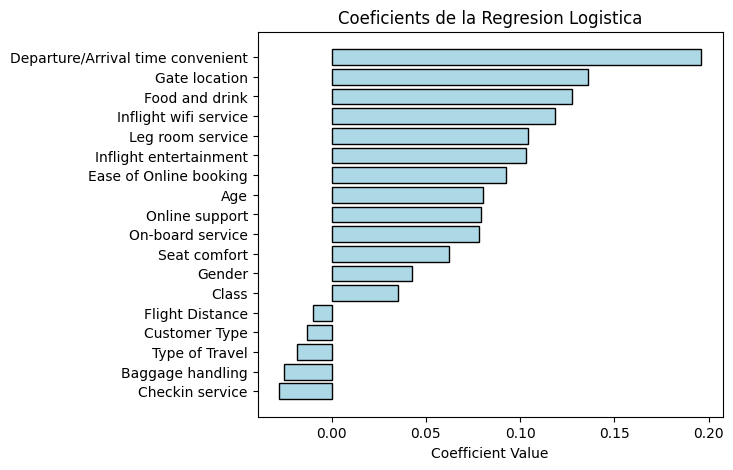

In [ ]:
coefficients, features = best_x[1:], column_names[1:]

sorted_indices = np.argsort(coefficients)
sorted_coefficients = coefficients[sorted_indices]
sorted_features = np.array(features)[sorted_indices]

plt.figure(figsize=(6, 5))
plt.barh(sorted_features, sorted_coefficients, color='lightblue', edgecolor='black')
plt.xlabel('Coefficient Value'), plt.title('Coeficients de la Regresion Logistica')
plt.show()

De acuerdo a lo que ve usted en la gráfica debe hacer algunas observaciones sobre los atributos del vuelo. En particular indique cuáles atributos generalmente contribuyen a una mayor probabilidad de satisfacción y cuáles a una mayor probabilidad de  insatisfacción. Explique su respuesta

## **Atributos que más contribuyen a una mayor probabilidad de satisfacción**

Los coeficientes más grandes indican mayor influencia positiva en la satisfacción del pasajero. En este caso, estos atributos tienen los coeficientes más altos:

1. **Departure/Arrival time convenient (~0.195)**
   → Si el horario de salida/llegada es conveniente, la satisfacción sube fuertemente. Tiene el mayor impacto positivo.

2. **Gate location (~0.14)**
   → Puertas de embarque accesibles o cómodas mejoran notablemente la experiencia.

3. **Food and drink (~0.13)**
   → Una buena experiencia gastronómica influye bastante en cómo el pasajero percibe el vuelo.

4. **Inflight wifi service (~0.12)**
   → Estar conectado en el aire es claramente un factor diferenciador hoy en día.

5. **Leg room service (~0.11)**
   → Tener suficiente espacio para las piernas hace toda la diferencia en la comodidad.

Otros atributos como Inflight entertainment, Ease of online booking, On-board service y Seat comfort también tienen coeficientes positivos importantes.

---

##  **Atributos que contribuyen menos a la satisfacción o incluso podrían estar asociados con la insatisfacción**

En la gráfica se observa que los siguientes atributos tienen coeficientes levemente negativos, lo que indica que podrían estar ligeramente asociados con una menor satisfacción del pasajero. Si bien su efecto no es fuerte, el modelo sugiere que estos factores, tal como están evaluados, podrían tener un impacto negativo (aunque bajo) en la percepción del servicio:

* **Checkin service**(el más negativo del grupo)
* **Baggage handling**
* **Type of Travel**
* **Customer Type**
* **Flight Distance**(el menos negativo)

## Interpretación:

* Aunque el impacto es bajo, estos atributos muestran una tendencia a estar asociados con menor satisfacción.

* El caso más notable es el Check-in service, lo cual sugiere que experiencias negativas en este punto podrían tener un efecto perceptible.

* Dado que el resto también presenta valores negativos, aunque menores, podría interpretarse que estos factores no generan valor diferencial, y en algunos casos incluso podrían restar.

* Es posible que estos aspectos no estén cumpliendo con las expectativas del pasajero, o bien que no se perciban como parte importante de la experiencia general del vuelo.

---

##  Conclusión general

Los resultados muestran que la satisfacción del pasajero está principalmente influenciada por factores que afectan directamente su comodidad y conveniencia durante el vuelo, siendo el horario de salida/llegada el atributo más decisivo. La ubicación de la puerta de embarque, la calidad de la comida y bebida, el acceso a WiFi a bordo y el espacio para las piernas también contribuyen significativamente a mejorar la experiencia. Por otro lado, algunos factores como el servicio de check-in muestran incluso una leve asociación negativa con la satisfacción, lo cual sugiere que una mala experiencia en este punto puede disminuir la percepción general del viaje. En general, los atributos logísticos tienen un impacto mucho menor que los relacionados con la experiencia directa del pasajero.

* Hay **atributos clave altamente valorados por los pasajeros**: horarios convenientes, ubicación de puertas, comida, wifi, espacio personal y entretenimiento.
* Otros factores como el check-in, tipo de viaje o distancia del vuelo **no influyen tanto**, al menos según tu modelo.

Esto tiene mas sentido en la práctica : la comodidad y conveniencia directa del pasajero durante el vuelo tiene mucho más peso que características logísticas o administrativas.